# Session 11 — Optimizers and Learning-Rate Schedules

A gradient gives a direction and not a distance. These five experiments measure
the rules that turn one into the other, on the Session 10 model and corpus.

| # | the question | where it is answered |
|---|---|---|
| 1 | Adam by hand for one weight and five gradients, against PyTorch | `experiments/e1_adam_by_hand.py` |
| 2 | bias correction off: twenty steps both ways, and when it stops mattering | `experiments/e2_bias_correction.py` |
| 3 | the update-to-weight ratio per layer, and where warmup stops changing it | `experiments/e3_update_ratio.py` |
| 4 | cosine against WSD, both stopped at step 200 | `experiments/e4_cosine_vs_wsd.py` |
| 5 | learning-rate sweeps at widths 256, 512 and 1,024, extrapolated to 4,096 | `experiments/e5_lr_width.py` |

## 0. Setup

In [1]:
import sys, pathlib, json, importlib.util
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from IPython.display import Markdown, Image, display
from src.report import machine

def experiment(name):
    spec = importlib.util.spec_from_file_location(name, ROOT / "experiments" / f"{name}.py")
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod

def show(name, image=True):
    display(Markdown((ROOT / "results" / f"{name}.md").read_text()
                     .replace(f"![]({name}.png)", "")))
    if image and (ROOT / "results" / f"{name}.png").exists():
        display(Image(str(ROOT / "results" / f"{name}.png")))

print(json.dumps(machine(), indent=2))

{
  "chip": "Apple M4",
  "platform": "macOS-26.6.2-arm64-arm-64bit-Mach-O",
  "python": "3.14.5",
  "torch": "2.13.0",
  "device": "mps"
}


## 1. Adam by hand

This runs live. It computes m, v, m̂, v̂ and the step for five gradients in plain
Python floats, then runs `torch.optim.Adam` on the same five gradients and
compares every quantity, in float64 and float32.

In [2]:
e1 = experiment("e1_adam_by_hand")
out = e1.main(verbose=False)
for r in out["hand"]:
    print(f"t={r['t']}  g={r['g']:.2f}  m={r['m']:.6f}  v={r['v']:.8f}  "
          f"m̂={r['m_hat']:.6f}  v̂={r['v_hat']:.6f}  step={r['step']:+.9f}")

t=1  g=0.50  m=0.050000  v=0.00025000  m̂=0.500000  v̂=0.250000  step=-0.001000000
t=2  g=0.40  m=0.085000  v=0.00040975  m̂=0.447368  v̂=0.204977  step=-0.000988126
t=3  g=0.60  m=0.136500  v=0.00076934  m̂=0.503690  v̂=0.256703  step=-0.000994140
t=4  g=0.45  m=0.167850  v=0.00097107  m̂=0.488078  v̂=0.243132  step=-0.000989847
t=5  g=0.55  m=0.206065  v=0.00127260  m̂=0.503199  v̂=0.255030  step=-0.000996425


In [3]:
show("e1_adam_by_hand", image=False)

# E1 · Adam by hand, checked against PyTorch

One weight starting at w = 1.0, five gradients [0.5, 0.4, 0.6, 0.45, 0.55], η = 0.001, β₁ = 0.9, β₂ = 0.999, ε = 1e-08. The hand column is plain Python floats following the five lines of Section 6.

## The hand computation

| t |    g |        m |          v |       m̂ |       v̂ |         step |     w after |
| : | ---: | -------: | ---------: | -------: | -------: | -----------: | ----------: |
| 1 | 0.50 | 0.050000 | 0.00025000 | 0.500000 | 0.250000 | -0.001000000 | 0.999000000 |
| 2 | 0.40 | 0.085000 | 0.00040975 | 0.447368 | 0.204977 | -0.000988126 | 0.998011874 |
| 3 | 0.60 | 0.136500 | 0.00076934 | 0.503690 | 0.256703 | -0.000994140 | 0.997017734 |
| 4 | 0.45 | 0.167850 | 0.00097107 | 0.488078 | 0.243132 | -0.000989847 | 0.996027887 |
| 5 | 0.55 | 0.206065 | 0.00127260 | 0.503199 | 0.255030 | -0.000996425 | 0.995031463 |

This reproduces the Section 6 table digit for digit at its printed precision. Every step is between 98.81% and 100.00% of η, although the gradients differ by 50% from smallest to largest. That is the property the session names: the gradient sets the direction, η sets the distance.

## The step, side by side (float64)

| t |            by hand |   torch.optim.Adam | |difference| |
| : | -----------------: | -----------------: | -----------: |
| 1 | -0.000999999980000 | -0.000999999980000 |      1.1e-18 |
| 2 | -0.000988125782298 | -0.000988125782298 |      3.3e-17 |
| 3 | -0.000994140046704 | -0.000994140046704 |      1.5e-17 |
| 4 | -0.000989846693133 | -0.000989846693133 |      4.6e-17 |
| 5 | -0.000996424710595 | -0.000996424710595 |      4.8e-17 |

## Agreement for every quantity

Worst relative error over the five steps, and the number of decimal places of agreement it implies (−log₁₀ of the relative error). PyTorch does not store m̂ or v̂; they are recovered from its own m, v and step counter.

| quantity | float64 rel. err | float64 decimals | float32 rel. err | float32 decimals |
| -------- | ---------------: | ---------------: | ---------------: | ---------------: |
| m        |          2.0e-16 |             15.7 |          1.6e-08 |              7.8 |
| v        |          1.7e-16 |             15.8 |          5.7e-08 |              7.2 |
| m_hat    |          2.3e-16 |             15.6 |          1.6e-08 |              7.8 |
| v_hat    |          2.2e-16 |             15.7 |          5.7e-08 |              7.2 |
| step     |          4.8e-14 |             13.3 |          1.4e-05 |              4.9 |
| w        |          0.0e+00 |            exact |          1.3e-08 |              7.9 |

**Float64: at least 13.3 decimal places on every quantity. Float32: at least 4.9.** In float32, m, v, m̂, v̂ and w all agree to 7–8 digits, which is float32's own resolution. The step is the outlier, and not because Adam disagrees: PyTorch never stores its step, so it is recovered as `w_after − w_before`. Both weights sit near 1.0, where float32 spacing is 1.2e-7, and the step is only 1e-3, so the subtraction alone throws away about four digits. Which is itself a Session 10 lesson: a 1e-3 update to a weight of 1 keeps only ~4 significant digits in float32, and none at all in bf16.

## AdamW, decay 0.1

The same five gradients through `torch.optim.AdamW` against the hand rule with the decoupled `− η·λ·w` term added after the Adam step. Worst agreement in float64: 13.1 decimals. The decay term alone moved the weight by -1.0e-04 at step 1, about 10% of η, and it is not divided by √v̂, which is the whole point of Section 7.

## A detail found by doing it

PyTorch does not compute the step the way Section 6 writes it. It folds both corrections into a scalar, `step_size = η / (1 − β₁ᵗ)` and `denom = √v / √(1 − β₂ᵗ) + ε`. ε is still added *after* the v correction, as in the formula, so the two routes are the same algorithm and differ only in rounding order. That is why float64 agrees to 15–16 digits on m, v, m̂ and v̂ rather than bit for bit. Step 1 also shows ε at work: the step is 0.99999998·η, not η, because ε = 1e-8 sits beside √v̂ = 0.5.


## 2. Bias correction off

The single-weight half has a closed form, so it is recomputed live: the
uncorrected step is exactly r(t) = (1 − β₁ᵗ)/√(1 − β₂ᵗ) times the corrected one.

In [4]:
e2 = experiment("e2_bias_correction")
for b2 in (0.999, 0.95):
    print(f"β₂={b2}:  r(1)={e2.r_of(1,b2):.2f}  r(10)={e2.r_of(10,b2):.2f}  "
          f"r(20)={e2.r_of(20,b2):.2f}  within 10% from step {e2.settle_step(b2,0.10):,}  "
          f"within 1% from step {e2.settle_step(b2,0.01):,}")

β₂=0.999:  r(1)=3.16  r(10)=6.53  r(20)=6.24  within 10% from step 1,751  within 1% from step 3,925
β₂=0.95:  r(1)=0.45  r(10)=1.03  r(20)=1.10  within 10% from step 6  within 1% from step 76


The model half trains twelve 300-step runs. Its evidence, from `run_all.py`:

# E2 · Bias correction off, twenty steps both ways



## A · One weight

Twenty gradients drawn uniformly from [0.4, 0.6] (seed 0), β₁ = 0.9. The step is shown in units of η. Corrected, it sits at ~1.0η throughout, as in E1. Uncorrected:

|  t |     g | corrected | uncorr. β₂=0.999 | ratio | uncorr. β₂=0.95 | ratio |
| -: | ----: | --------: | ---------------: | ----: | --------------: | ----: |
|  1 | 0.527 |    1.0000 |           3.1623 | 3.162 |          0.4472 | 0.447 |
|  2 | 0.454 |    0.9934 |           4.2214 | 4.250 |          0.6056 | 0.608 |
|  3 | 0.408 |    0.9856 |           4.8790 | 4.950 |          0.7103 | 0.718 |
|  4 | 0.403 |    0.9820 |           5.3439 | 5.442 |          0.7888 | 0.798 |
|  5 | 0.563 |    0.9930 |           5.7565 | 5.797 |          0.8541 | 0.861 |
|  6 | 0.583 |    1.0015 |           6.0657 | 6.057 |          0.9065 | 0.910 |
|  7 | 0.521 |    1.0036 |           6.2671 | 6.245 |          0.9476 | 0.950 |
|  8 | 0.546 |    1.0071 |           6.4240 | 6.379 |          0.9816 | 0.982 |
|  9 | 0.509 |    1.0064 |           6.5112 | 6.470 |          1.0074 | 1.007 |
| 10 | 0.587 |    1.0126 |           6.6099 | 6.528 |          1.0314 | 1.028 |
| 11 | 0.563 |    1.0154 |           6.6599 | 6.559 |          1.0499 | 1.045 |
| 12 | 0.401 |    0.9986 |           6.5592 | 6.569 |          1.0521 | 1.058 |
| 13 | 0.571 |    1.0050 |           6.5937 | 6.561 |          1.0668 | 1.069 |
| 14 | 0.407 |    0.9906 |           6.4780 | 6.539 |          1.0655 | 1.077 |
| 15 | 0.546 |    0.9961 |           6.4809 | 6.507 |          1.0759 | 1.084 |
| 16 | 0.435 |    0.9869 |           6.3804 | 6.465 |          1.0750 | 1.089 |
| 17 | 0.573 |    0.9961 |           6.3908 | 6.416 |          1.0844 | 1.092 |
| 18 | 0.508 |    0.9962 |           6.3378 | 6.362 |          1.0874 | 1.095 |
| 19 | 0.460 |    0.9902 |           6.2413 | 6.303 |          1.0852 | 1.096 |
| 20 | 0.485 |    0.9884 |           6.1686 | 6.241 |          1.0852 | 1.097 |

Dividing the two update rules gives the ratio in closed form, r(t) = (1 − β₁ᵗ) / √(1 − β₂ᵗ), independent of the gradients. So for a single weight the question has an exact answer:

|    β₂ | largest overshoot | at step 20 | within 10% from step | within 1% from step |
| ----: | ----------------: | ---------: | -------------------: | ------------------: |
| 0.999 |  6.57× at step 12 |      6.24× |                1,751 |           **3,925** |
|  0.95 |  1.10× at step 20 |      1.10× |                    6 |              **76** |

Over the first twenty steps the uncorrected weight travels 119.5η instead of 19.9η at β₂ = 0.999 (19.0η at β₂ = 0.95).

**The session's step-1 figure of 3.16η is only the beginning.** With β₂ = 0.999 the uncorrected step keeps *growing* after step 1, because m fills in a hundred times faster than v. It peaks at 6.57η at step 12, is still 6.24η at step 20, and then takes thousands of steps to come back: v's correction factor is √(1 − 0.999ᵗ), which is still 0.80 at step 1,000.

**With β₂ = 0.95, the value we train with, the error runs the other way first.** Step 1 is only 0.45η. The square root softens v's bias: uncorrected, √v = √(1 − β₂)·|g| = 0.22|g| while m = (1 − β₁)·g = 0.10g. Step 1 is too small whenever √(1 − β₂) > 1 − β₁, which is whenever β₂ < 0.99. The ratio then overshoots to 1.10η at step 20 and is within 1% from step 76. The answer to "after how many steps does it stop mattering" is therefore a property of β₂, roughly 4/(1 − β₂) steps for the 1% level, and not a fixed number.

## B · The width-256 model

Peak lr 1.0e-03 (best point of E5's width-256 sweep), 300 steps, cosine to 10%. Corrected and uncorrected runs use the same seed and the same batches. Validation loss is measured every 10 steps. The noise yardstick is the median |Δ val loss| between two corrected runs that differ only in seed, over steps 100–300.

|    β₂ | warmup | Δ val at step 20 |      largest Δ val | Δ val at 300 | seed noise | gap inside noise from | gap frozen from |
| ----: | -----: | ---------------: | -----------------: | -----------: | ---------: | --------------------: | --------------: |
| 0.999 |      0 |          +0.1280 | +0.7124 (step 150) |      +0.6741 |     0.0648 |                 never |         **100** |
| 0.999 |     30 |          -0.7575 | +0.6828 (step 300) |      +0.6828 |     0.0125 |                 never |         **270** |
|  0.95 |      0 |          -0.0209 |   +0.2981 (step 5) |      -0.3353 |     0.0654 |                 never |         **160** |
|  0.95 |     30 |          -0.0366 | +0.1614 (step 190) |      +0.1389 |     0.0755 |                 never |          **60** |

Δ is uncorrected minus corrected: positive means the uncorrected run is worse. "Gap inside noise from" asks whether the two runs become indistinguishable. "Gap frozen from" asks the weaker question, whether bias correction has stopped *changing* anything: the first evaluation after which the gap stays within seed noise of its final value.

## What the model adds to the closed form

**The loss never forgets the first few dozen steps.** In none of the four settings does the uncorrected run come back inside seed noise within 300 steps. The step rule itself stops differing on schedule (from step 76 at β₂ = 0.95), but the weights it produced in the meantime are different weights, and a 300-step run at a decaying learning rate has no time to undo that. What does stop is the *change*: the gap freezes at the steps in the last column and is a constant offset after that.

**β₂ = 0.999: it matters for the whole run, in both directions.** With warmup, the uncorrected run is ahead by 0.76 nats at step 20, because a 6× step during warmup is simply a larger learning rate, and larger is faster at first. It is behind from step ~40 and finishes +0.68 worse, because the 3–6× step persists long after it stopped helping. That matches the closed form: the ratio is still 1.96 at step 300.

**β₂ = 0.95 without warmup: turning correction off *helped*, by 0.34 nats.** The uncorrected first step is 0.45η and it climbs to η over about ten steps, so for any β₂ below 0.99 dropping bias correction is an accidental warmup. It is a worse warmup than a real one, though: the corrected run *with* 30 warmup steps finished at 4.216, below the uncorrected no-warmup run's 4.265.

**β₂ = 0.95 with warmup, our setting: +0.14 against seed noise of 0.08.** Small, about two noise widths, and frozen early. Warmup had already done the job bias correction was protecting, so turning it off only made the first steps timid for no benefit.


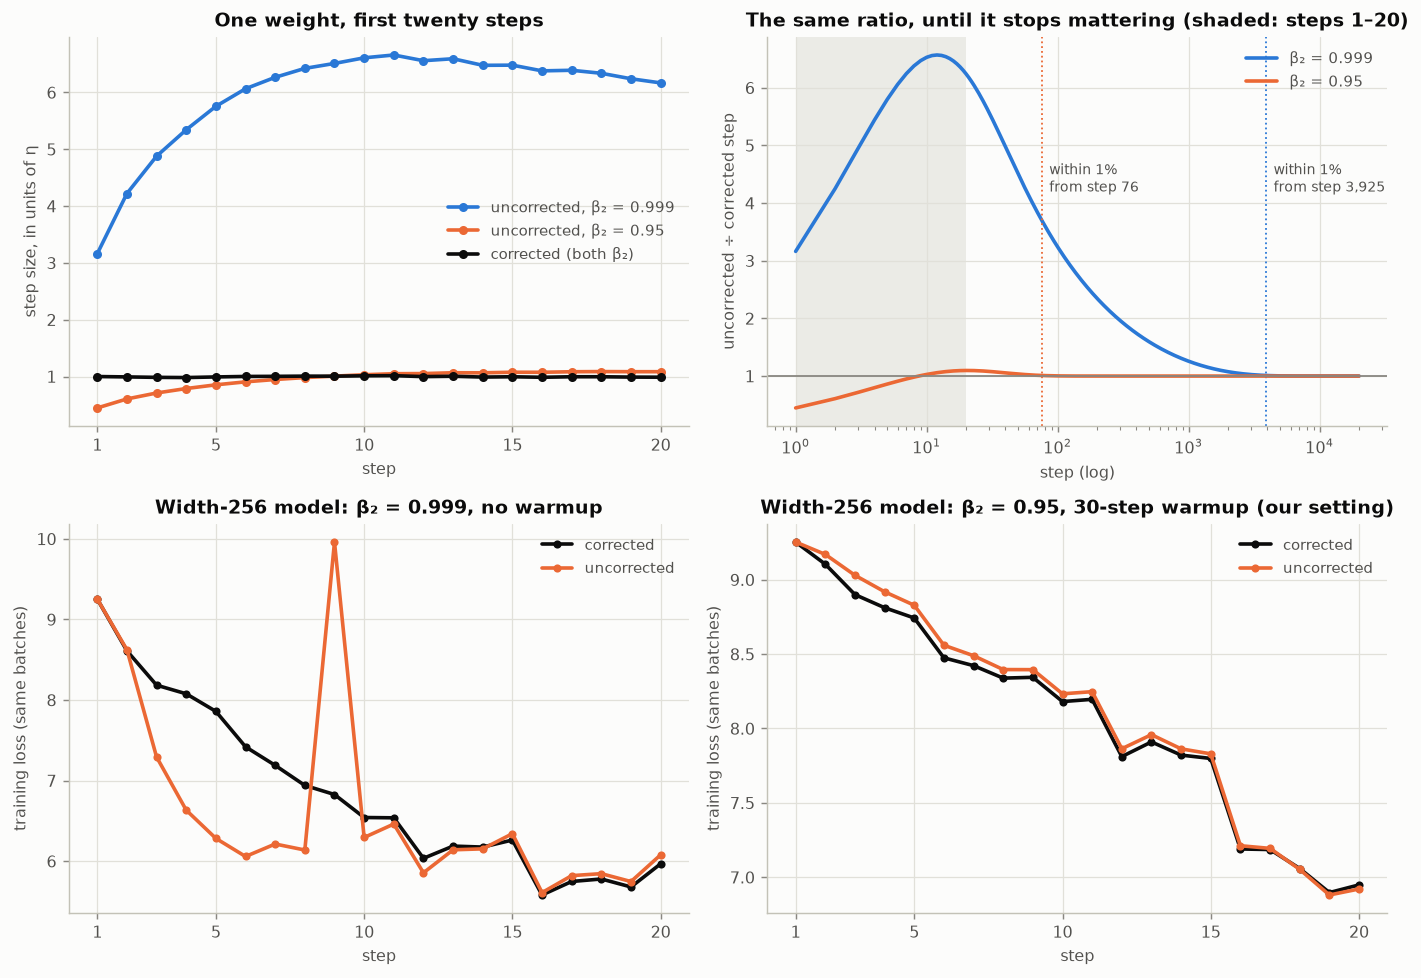

In [5]:
show("e2_bias_correction")

## 3. Update-to-weight ratio, per layer

# E3 · Update-to-weight ratio, per layer, and the end of warmup

Width-256 model, peak lr 1.0e-03 (best point of E5's width-256 sweep), 300 steps. One cosine to 10% for every run, with a warmup multiplier min(1, (t+1)/W) laid over it, so after step W the learning rates are identical. Ratio = ‖W_after − W_before‖ / ‖W_before‖ for each of the 19 weight matrices, at every step. A second no-warmup run with seed 1 supplies the noise band.



## When warmup stops changing the ratio

All measured on the median-over-layers ratio, smoothed over 9 steps, against the no-warmup run. The noise band is how far two no-warmup runs with different seeds sit apart (±9%).

- **Stops driving it**: the step at which the ratio peaks.
- **Rejoins**: the first step after the peak at which the warmed-up curve is inside the noise band of the no-warmup curve.
- **Late offset**: the median gap between the two curves over steps 150–300. The same number for two no-warmup seeds is +1.0%.
- **‖W‖ ratio**: final weight norm without warmup ÷ with it, median over layers.
- **Stays inside**: the first step after which the curve never leaves the band again.

| warmup W | stops driving it | rejoins | late offset | ‖W‖ no-warmup ÷ warmup | stays inside | peak ratio | val loss @300 |
| -------: | ---------------: | ------: | ----------: | ---------------------: | -----------: | ---------: | ------------: |
|        0 |                1 |       — |           — |                      — |            — |   4.99e-02 |        4.6002 |
|       25 |           **31** |  **31** |       +8.6% |                  1.047 |          291 |   1.15e-02 |        4.2970 |
|       50 |           **52** |  **65** |       +7.7% |                  1.058 |          296 |   1.06e-02 |        4.1701 |
|      100 |           **98** |  **98** |       +8.6% |                  1.073 |          298 |   7.76e-03 |        4.1711 |

**Warmup stops driving the ratio exactly when it ends.** The median ratio peaks at step 31, 52 and 98 for W = 25, 50 and 100: the ratio climbs with η for W steps and then follows the shared schedule down. It rejoins the no-warmup curve at step 31, 65 and 98, which is the answer to the assignment's question: **past that step, warmup is no longer changing the ratio.** Layer by layer (table below) the rejoin step has a median of 36 / 65 / 106 for W = 25 / 50 / 100, so it tracks W rather than any fixed step.

**What it leaves behind is a small permanent offset, and the offset is in the weights.** From step 150 on, the warmed-up runs' ratio sits +9% / +8% / +9% above the no-warmup run's, against +1% between two no-warmup seeds. That is why the "stays inside" column lands near step 300: the curves touch the band's edge rather than sit inside it. Most of the cause is in the denominator. The no-warmup run's weights finish +5.8% larger (median over layers, against W = 50), because its first steps were 1/20 of each weight in size and pushed every matrix outward. A larger ‖W‖ divides the same Adam step into a smaller ratio, which accounts for roughly 6 of the 8 points; the rest is inside what one extra seed can move. (The norms come from re-running each arm once with the same seed, since the first pass did not record them.)

**The largest ratio the run ever sees** is 5.0e-02 without warmup, at step 1, and 1.2e-02 / 1.1e-02 / 7.8e-03 with W = 25 / 50 / 100. Section 9 quotes 19.2e-3 against 2.83e-3 at d_model 4,096. Our starting ratio is larger because every matrix is initialised at 0.02 whatever its width, so a full η = 1e-3 step is 1/20 of a weight of typical size 0.02. By step 300 every run is at the healthy 1e-3 (1.03e-03 without warmup, 1.06e-03 with W = 50).

**Where warmup paid off.** Validation loss at step 300 was 4.600 without warmup (a second seed: 4.673), 4.297 with 25 steps, 4.170 with 50 and 4.171 with 100. Fifty steps bought 0.43 nats. Doubling to 100 bought nothing more.

## Every layer

Step-1 ratio for the no-warmup run, peak and peak step with W = 50, step-300 ratio without warmup, the layer's seed-noise band, then the step at which that layer's ratio rejoins the no-warmup curve for each warmup length.

| layer   | step 1, W=0 | peak, W=50 | peak step | step 300 | noise band | W=25 | W=50 | W=100 |
| ------- | ----------: | ---------: | --------: | -------: | ---------: | ---: | ---: | ----: |
| tok_emb |    1.46e-02 |   6.75e-03 |        52 | 5.74e-04 |        ±3% |   45 |   57 |   151 |
| pos_emb |    3.55e-02 |   9.64e-03 |        50 | 8.75e-04 |        ±8% |   42 |   50 |   104 |
| b0.qkv  |    4.99e-02 |   1.54e-02 |        52 | 1.03e-03 |        ±7% |   38 |   91 | never |
| b0.proj |    4.99e-02 |   1.00e-02 |        48 | 9.90e-04 |       ±13% |   36 |   55 | never |
| b0.fc   |    5.00e-02 |   1.14e-02 |        52 | 9.47e-04 |        ±8% |  261 |  251 | never |
| b0.out  |    4.99e-02 |   1.09e-02 |        52 | 9.62e-04 |        ±8% |   31 |  180 |   248 |
| b1.qkv  |    4.99e-02 |   1.35e-02 |        52 | 1.01e-03 |       ±21% |   56 |   55 |    52 |
| b1.proj |    4.99e-02 |   9.04e-03 |        52 | 1.12e-03 |       ±13% |   36 |   59 |   108 |
| b1.fc   |    4.99e-02 |   1.12e-02 |        52 | 1.03e-03 |        ±8% |   31 |  210 |   210 |
| b1.out  |    4.99e-02 |   1.11e-02 |        47 | 1.04e-03 |        ±8% |   31 |   65 |    76 |
| b2.qkv  |    4.95e-02 |   1.42e-02 |        47 | 9.29e-04 |       ±21% |   26 |   47 |   107 |
| b2.proj |    4.98e-02 |   9.44e-03 |        47 | 1.10e-03 |       ±12% |   44 |   47 |   112 |
| b2.fc   |    5.00e-02 |   1.14e-02 |        47 | 1.04e-03 |       ±11% |   31 |   82 |    76 |
| b2.out  |    5.00e-02 |   1.08e-02 |        47 | 1.07e-03 |        ±8% |   31 |   66 |    82 |
| b3.qkv  |    4.94e-02 |   1.52e-02 |        47 | 9.94e-04 |       ±15% |   42 |   47 |    80 |
| b3.proj |    4.99e-02 |   9.18e-03 |        47 | 1.07e-03 |        ±9% |   82 |  109 |   126 |
| b3.fc   |    5.00e-02 |   1.12e-02 |        47 | 1.02e-03 |       ±13% |   31 |   60 |    76 |
| b3.out  |    5.01e-02 |   9.91e-03 |        47 | 1.11e-03 |        ±8% |   15 |   65 |    98 |
| head    |    4.98e-02 |   2.42e-02 |        33 | 1.03e-03 |        ±5% |   83 |  177 |   221 |

## Why warmup is needed at all

The right-hand panel divides the ratio by the learning rate. That removes everything the schedule does and leaves what Adam does with the gradients it is given. Without warmup, the median ratio per unit η is 27.4 over the first five steps and 10.1 over the last fifty, 2.7× higher at the start. That is Section 9's argument measured: early gradients agree with each other, so m̂/√v̂ is near 1 for most weights and every weight takes close to a full η step. Warmup cannot change that ratio per unit η. It can only keep η small while it is high.


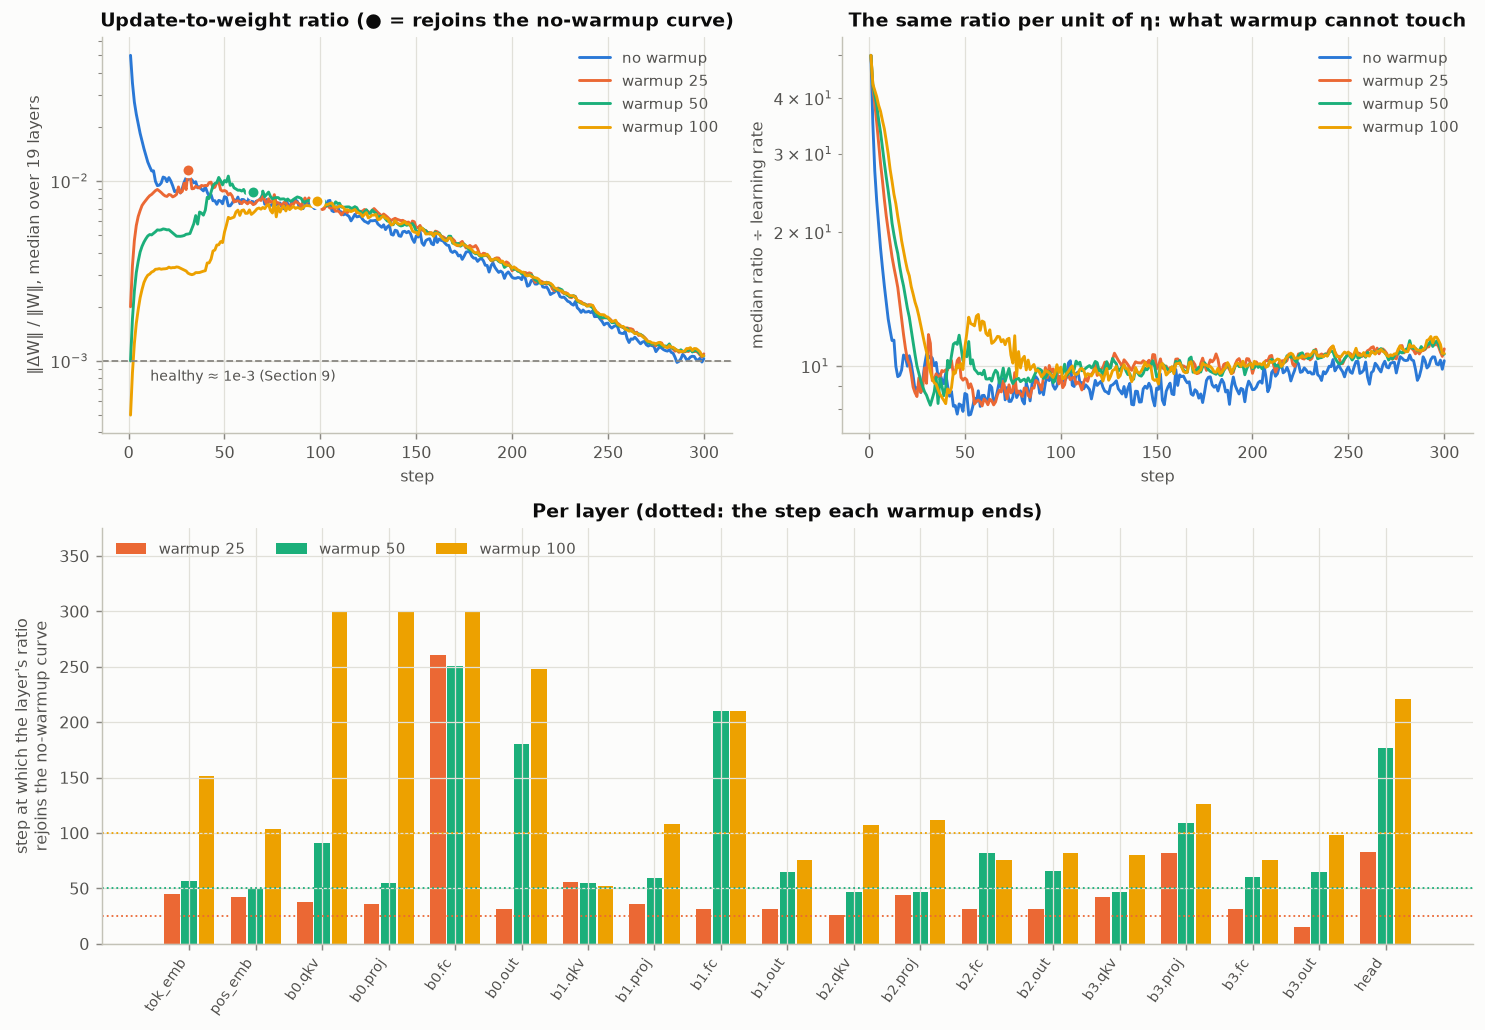

In [6]:
show("e3_update_ratio")

## 4. Cosine against WSD

# E4 · Cosine against WSD, stopped at step 200

Width-256 model. Both schedules planned for 300 steps, 30 steps of warmup, decay to zero. WSD decays over the last 20%. Three seeds at each schedule's own tuned rate. Mean ± sample std of held-out loss.



## 1 · Tuning both sides first

Seed 0, each rate a full 300-step run. Each schedule is tuned on the step-300 loss, the number it was designed to deliver.

|  peak lr | cosine @300 | WSD @300 | cosine @200 | WSD @200 |
| -------: | ----------: | -------: | ----------: | -------: |
| 5.00e-04 |      4.4054 |   4.1332 |      4.4885 |   4.3642 |
| 7.07e-04 |      4.3097 |   4.0658 |      4.4000 |   4.2966 |
| 1.00e-03 |      4.2792 |   4.0398 |      4.3852 |   4.2966 |
| 1.41e-03 |      4.3869 |   4.1546 |      4.5119 |   4.4763 |
| 2.00e-03 |      4.5573 |   4.4029 |      4.6481 |   4.6179 |
| 2.83e-03 |      4.6614 |   4.5178 |      4.7708 |   4.7592 |

Chosen: cosine **1.00e-03**, WSD **1.00e-03**.

## 2 · The comparison, three seeds

| model                                   | lr at the stop (÷ peak) |        val loss |
| --------------------------------------- | ----------------------: | --------------: |
| cosine, stopped at 200                  |                     31% | 4.3685 ± 0.0524 |
| WSD, stopped at 200                     |                    100% | 4.2891 ± 0.0431 |
| WSD, step-160 checkpoint decayed to 200 |                      0% | 4.3035 ± 0.0461 |
| cosine planned for 200 (reference)      |                      0% | 4.5794 ± 0.0582 |
| cosine, completed at 300                |                      0% | 4.2670 ± 0.0480 |
| WSD, completed at 300                   |                      0% | 4.0461 ± 0.0201 |

WSD stopped minus cosine stopped: **-0.0794**. WSD branch minus cosine stopped: **-0.0649**. At the planned end, WSD minus cosine: -0.2209.

Because every pair shares a seed, and so the same initialisation and the same batches, the differences are better judged per seed than from the two spreads:

| paired difference (negative = first is better) |              seed 0 / 1 / 2 |           mean ± std |
| ---------------------------------------------- | --------------------------: | -------------------: |
| WSD stopped − cosine stopped                   | -0.0887 / -0.0669 / -0.0826 | **-0.0794 ± 0.0112** |
| WSD branch − WSD stopped                       | +0.0217 / +0.0091 / +0.0125 |     +0.0145 ± 0.0065 |
| cosine planned for 200 − cosine stopped        | +0.2118 / +0.2048 / +0.2163 |     +0.2110 ± 0.0058 |

## The model I would keep: WSD's step-200 checkpoint

**It is the lower loss, on every seed**, by 0.079 nats on average (every seed between 0.067 and 0.089). And it is the only one of the two that is still a *usable* checkpoint rather than an end point. It sits at the peak learning rate with nothing spent, so it can resume toward 300 or beyond, or be handed a short decay whenever a finished model is needed. The cosine model at step 200 has already spent 69% of its learning rate on a decay aimed at step 300, and resuming it means continuing a schedule that was written for a different run.

## What was not expected

**On this model, at this length, decaying bought less than it cost.** Section 10 expects a model stopped mid-decay to be worse than one planned for that length, and a WSD checkpoint to need its decay before it is competitive. Both came out the other way:

- Cosine *planned* for 200 steps finished +0.211 worse than the 300-step cosine halted at 200.

- Decaying the WSD run from step 160 to 0 over 40 steps ended +0.014 worse than simply stopping it at full rate.

The common cause is that 200 to 300 steps of 4,096 tokens is far from converged for this model. The loss is still falling by about 0.5 nats per hundred steps around step 200, so steps taken at the peak are worth more than the noise suppression a decay buys. Any schedule that spends less time at the peak loses, and the ranking follows the area under each learning-rate curve. On a run long enough to plateau, the decay's benefit is known to reappear, which is why the WSD result that transfers is the flexibility, not the margin.

**One caveat on the planned-200 cosine:** it used the peak rate tuned for a 300-step cosine, not one tuned for 200 steps. It is a reference, not a tuned competitor, and it is not part of the comparison the assignment asks for.

**Why both sides had to be tuned.** Both schedules have their minimum at the same peak here, so a comparison at 1e-3 happens to be fair. At any other single rate it is not, and a mismatched pair can reverse the verdict or inflate it. From the tuning table, at step 200:

| comparison                                | cosine @200 | WSD @200 | WSD − cosine |
| ----------------------------------------- | ----------: | -------: | -----------: |
| both tuned (the comparison above, seed 0) |       4.385 |    4.297 |       -0.089 |
| tuned cosine vs WSD at 2.83e-03           |       4.385 |    4.759 |   **+0.374** |
| cosine at 2.83e-03 vs tuned WSD           |       4.771 |    4.297 |   **-0.474** |

The same two schedules can be reported as cosine winning by 0.37, as WSD winning by 0.09, or as WSD winning by 0.47, depending only on which side was given its best rate. That is the session's closing warning, reproduced on a 300-step run.


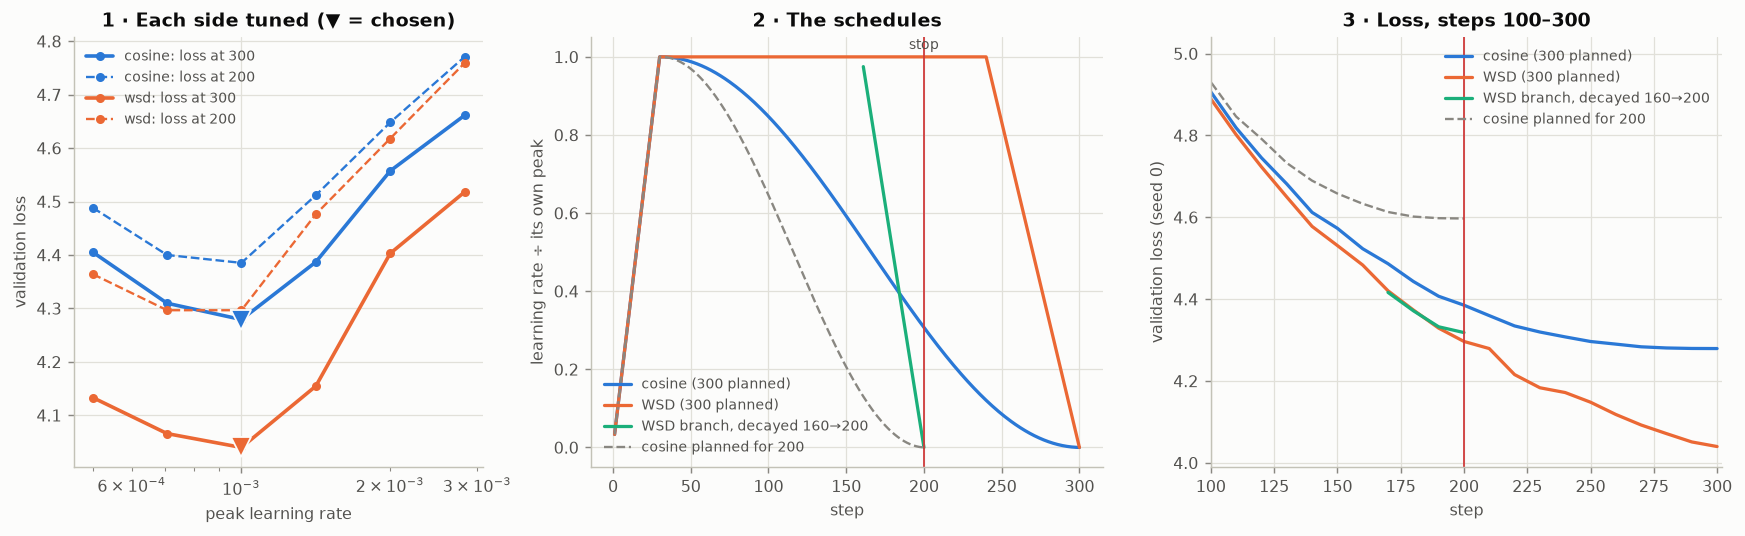

In [7]:
show("e4_cosine_vs_wsd")

## 5. Learning rate against width

# E5 · Learning rate against width

Standard parameterisation, 4 layers, 300 steps × 4,096 tokens, 30-step warmup, cosine to 10% of peak, AdamW (0.9, 0.95), decay 0.1, clip 1.0. Score: held-out loss over 65,536 tokens.



## Every point (seed 0; half-octave points only near each minimum)

|  peak lr | width 256 | width 512 | width 1,024 |
| -------: | --------: | --------: | ----------: |
| 1.25e-04 |    5.2357 |    4.6513 |      4.3654 |
| 2.50e-04 |    4.6842 |    4.3202 |      4.1523 |
| 3.54e-04 |         — |    4.2133 |      4.1023 |
| 5.00e-04 |    4.3461 |    4.1548 |      4.0853 |
| 7.07e-04 |    4.2502 |    4.2277 |      4.0589 |
| 1.00e-03 |    4.2155 |    4.2850 |      4.1544 |
| 1.41e-03 |    4.3146 |         — |           — |
| 2.00e-03 |    4.5099 |    4.4093 |      4.3236 |
| 4.00e-03 |    4.5543 |    4.6313 |      4.6645 |
| 8.00e-03 |    4.8621 |    4.9552 |      5.1031 |

## The three minima

The minimum is the vertex of a parabola in log₂(lr) through five points around the lowest loss: the grid minimum, its two neighbours (two seeds each, averaged) and two half-octave points (one seed). Per-seed minima refit seed 0 alone on five points and seed 1 alone on three.

| width | params | best grid lr | val loss | fitted minimum |     per-seed minima |
| ----: | -----: | -----------: | -------: | -------------: | ------------------: |
|   256 |   8.3M |     1.00e-03 |   4.2155 |   **8.96e-04** | 8.76e-04 – 9.36e-04 |
|   512 |  23.0M |     5.00e-04 |   4.1548 |   **5.11e-04** | 5.11e-04 – 5.15e-04 |
| 1,024 |  71.1M |     5.00e-04 |   4.0853 |   **5.05e-04** | 4.69e-04 – 5.17e-04 |

## Extrapolating to 4,096

A straight line through the three minima in log–log space has slope **-0.41** (per-seed combinations: -0.50 to -0.38). Section 12's rule of thumb is −1.00.

| estimate for d_model 4,096                    |     learning rate |
| --------------------------------------------- | ----------------: |
| fit through the three minima                  |       **2.6e-04** |
| range over per-seed minima                    | 2.2e-04 – 2.8e-04 |
| 1/width, anchored at our width-1,024 minimum  |           1.3e-04 |
| the 512 → 1,024 slope alone, continued        |           4.9e-04 |
| carrying width 256's minimum across unchanged |           9.0e-04 |

## The value I would use, and how confident I am

**2.6e-04**, as the centre of a short confirmation sweep at the real width, not as a value to launch with.

**Confidence: low, roughly a factor of two either way.** The per-seed range above looks tight, but it only measures seed noise at these three widths. It does not measure the thing that dominates the error, which is the shape of the curve:

- The minimum does not move as a clean power law. From 256 to 512 the local slope is -0.81; from 512 to 1,024 it is -0.02. Three points cannot tell a power law from a curve that is flattening, and the two readings give 2.6e-04 and 4.9e-04 at 4,096.

- Section 12's −1 rule, anchored at our width-1,024 minimum, gives 1.3e-04, another factor of two lower. Our measured slope is about half as steep, and there is a concrete reason to expect that here. This model initialises every matrix at a fixed 0.02. Under a textbook 1/√fan-in initialisation the weights shrink as the model widens, so the same η is a relatively larger step on a wider model, and that is part of why the optimum moves left. With a fixed 0.02 the step-to-weight ratio at a given η is the same at every width (E3 measures it), so that part of the drift is absent. What remains comes from wider layers summing more correlated updates. That argument predicts a shallower slope, not its exact value. A second, untested possibility is the 300-step budget, which leaves every width far from converged.

- 4,096 is four times wider than the widest point measured, and the vocabulary (10k) and depth (4) would not be the real ones.

**What would raise it:** a fourth width at 2,048 to decide between the power law and the flattening curve, and a longer budget, since the optimum at 300 steps is not the optimum at 30,000. Or muP, which Section 12 exists to recommend: under it this whole table collapses to one column and the question disappears.



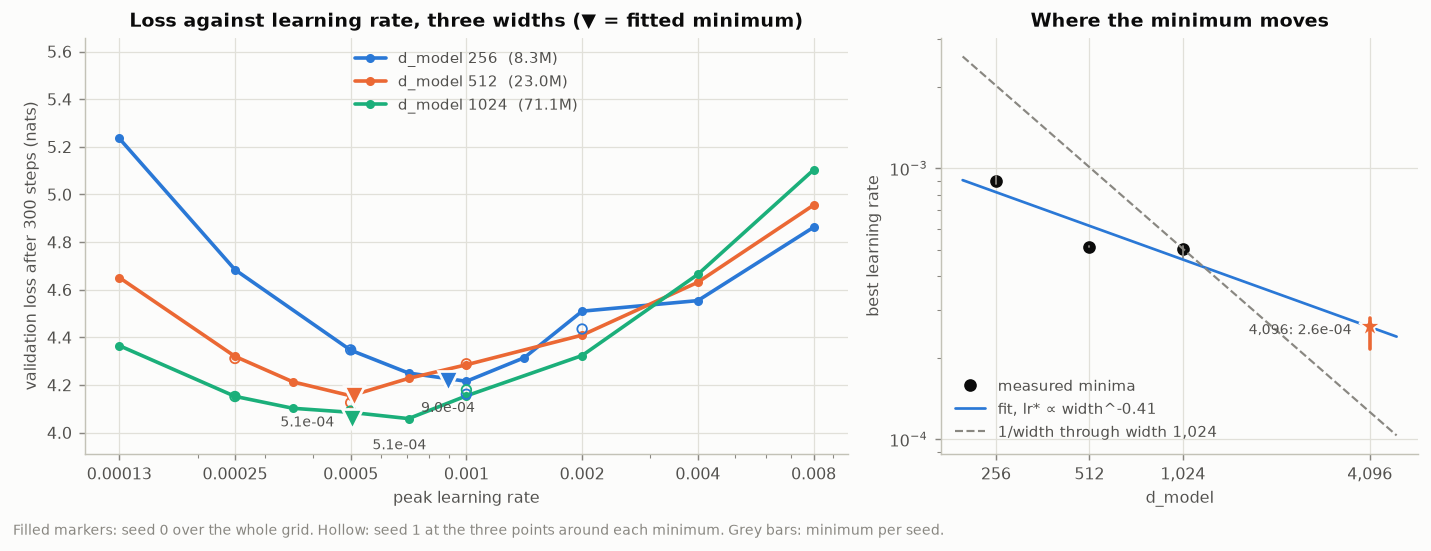

In [8]:
show("e5_lr_width")